# Section 1: Data exploration

In [1]:
words = open("names.txt", "r").read().splitlines()

In [2]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
len(words)

32033

In [4]:
min(len(w) for w in words)

2

In [5]:
max(len(w) for w in words)

15

# Section 2: Bigram Model

In [8]:
import torch

In [9]:
# 28 by 28 as there are 26 letters in the alphabet + 1 special character
N = torch.zeros((27, 27), dtype=torch.int32)


In [10]:
chars = sorted(list(set("".join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi["."] = 0
itos = {i:s for s, i in stoi.items()}

In [11]:
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [31]:
for w in words:
    chs = ['.'] + list(w) + ["."]
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

(-0.5, 26.5, 26.5, -0.5)

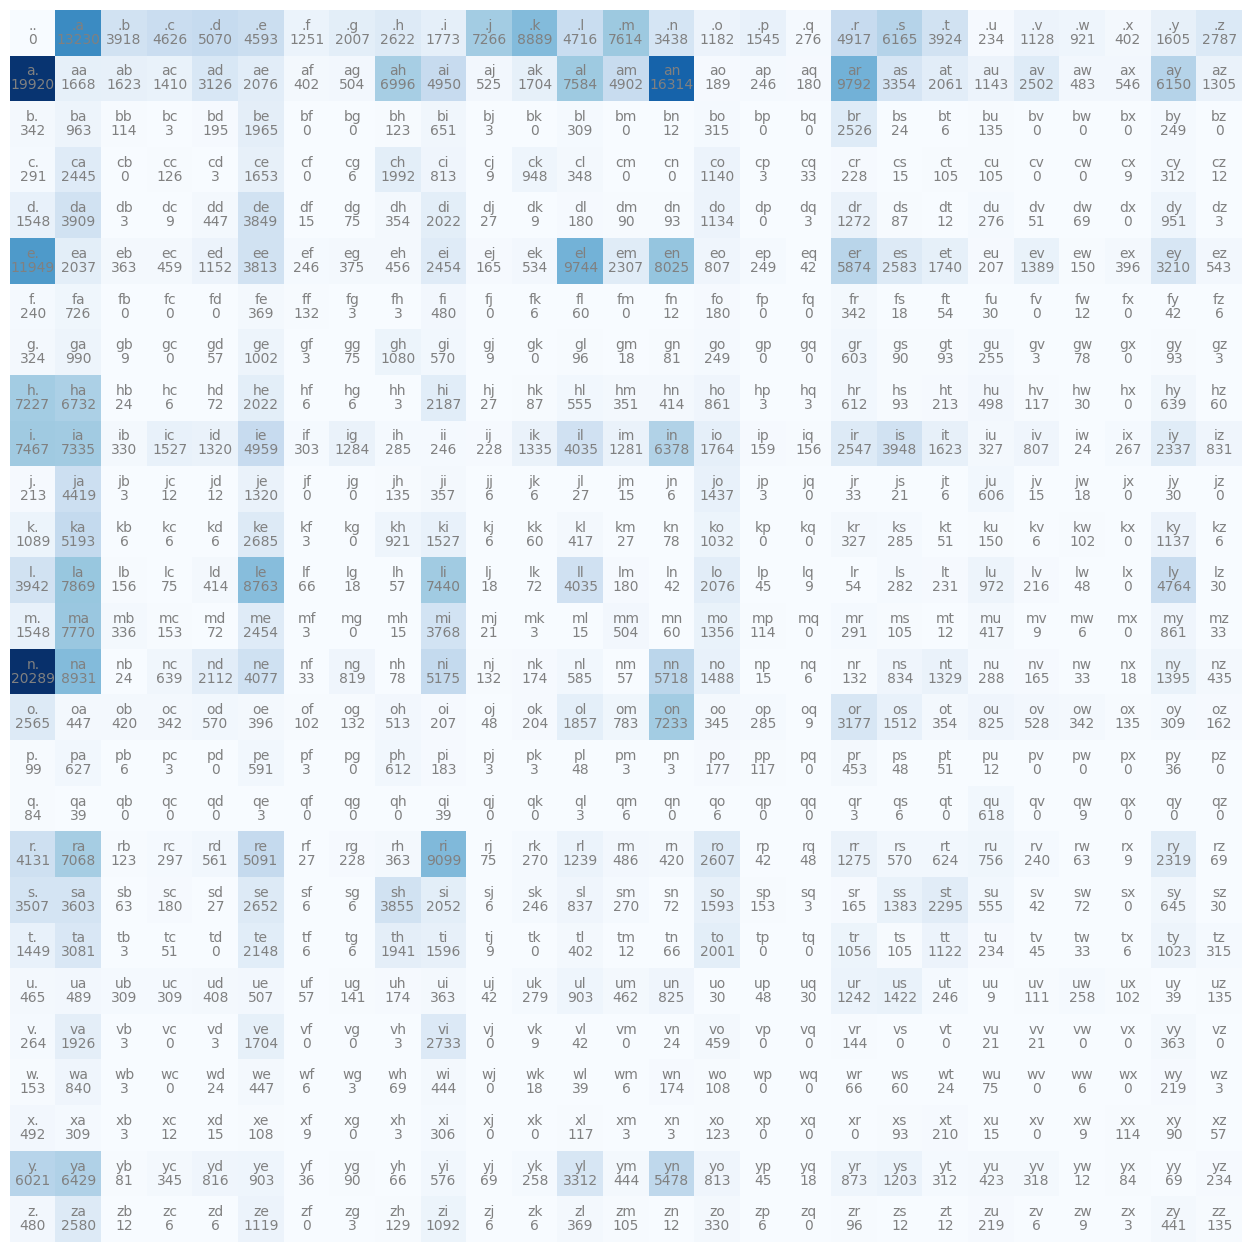

In [32]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off')

In [40]:
N[0]

tensor([    0, 13230,  3918,  4626,  5070,  4593,  1251,  2007,  2622,  1773,
         7266,  8889,  4716,  7614,  3438,  1182,  1545,   276,  4917,  6165,
         3924,   234,  1128,   921,   402,  1605,  2787], dtype=torch.int32)

In [56]:
# for efficiency - vectorized normalization of the rows using tensor broadcasting
# +1 is for smoothing (preventing any probabilities with value 0)
P = (N+1).float()
P /= P.sum(1, keepdim=True)


In [57]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if(ix == 0):
            break

    print("".join(out))

junide.
janasah.
p.
cony.
a.


In [58]:
# Goal: To maximize likelihood of the data w.r.t. model parameters (currently its the probabilities in the bigram table above).
# equivalent to maximizing the log likelihood (because log is monotonic)
# equivalent to minimizing the negative log likelihood
# equivalent to minimizing the average negative log likelihood

log_likelihood = 0.0
n = 0


for w in words:
    chs = ['.'] + list(w) + ["."]
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        # print(f'{ch1}{ch2}: {prob:.4f} {logprob: .4f}')

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f"{nll=}")
print(f"{nll/n=}")

log_likelihood=tensor(-559943.5000)
nll=tensor(559943.5000)
nll/n=tensor(2.4543)


# Section 3: Neural Network Approach

In [113]:
# create the training set of bigrams

xs, ys = [], []

for w in words:
    chs = ['.'] + list(w) + ["."]
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs) # inputs to the neural net
ys = torch.tensor(ys) # labels for the correct next character
num = xs.nelement()
print("number of examples: ", num)

# initialize the network
# randomly initialize 27 neurons' weights, with each neuron receiving 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn(27, 27, generator=g, requires_grad=True)

number of examples:  228146


In [ ]:
import torch.nn.functional as F

# utilize OHE in order to treat each character as its own independent category with no implied relationships between them
xenc = F.one_hot(xs, num_classes=27).float()
xenc

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 1., 0., 0.]])

In [ ]:
# gradient descent

for k in range(100):
    # forward pass
    logits = (xenc @ W) # interpret as log-counts
    counts = logits.exp() # equivalent to our N array above!
    probs = counts / counts.sum(1, keepdims=True) # normalize to get probability distribution (this and above operation is softmax)
    # probs[torch.arange, ys] these are the probabilities that the neural network assigns to the CORRECT next character
    loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean() # add regularization (same thing like laplace smoothing we did with bigram, the greater we set the rate (0.01), the less possible these weights are able to grow)
    print(loss.item())

    # backward pass
    W.grad = None
    loss.backward()

    # update 
    W.data += -50 * W.grad

tensor(3.7590, grad_fn=<NegBackward0>)
tensor(3.3711, grad_fn=<NegBackward0>)
tensor(3.1540, grad_fn=<NegBackward0>)
tensor(3.0204, grad_fn=<NegBackward0>)
tensor(2.9277, grad_fn=<NegBackward0>)
tensor(2.8604, grad_fn=<NegBackward0>)
tensor(2.8097, grad_fn=<NegBackward0>)
tensor(2.7701, grad_fn=<NegBackward0>)
tensor(2.7381, grad_fn=<NegBackward0>)
tensor(2.7115, grad_fn=<NegBackward0>)
tensor(2.6890, grad_fn=<NegBackward0>)
tensor(2.6697, grad_fn=<NegBackward0>)
tensor(2.6529, grad_fn=<NegBackward0>)
tensor(2.6383, grad_fn=<NegBackward0>)
tensor(2.6254, grad_fn=<NegBackward0>)
tensor(2.6140, grad_fn=<NegBackward0>)
tensor(2.6039, grad_fn=<NegBackward0>)
tensor(2.5948, grad_fn=<NegBackward0>)
tensor(2.5867, grad_fn=<NegBackward0>)
tensor(2.5794, grad_fn=<NegBackward0>)
tensor(2.5728, grad_fn=<NegBackward0>)
tensor(2.5668, grad_fn=<NegBackward0>)
tensor(2.5613, grad_fn=<NegBackward0>)
tensor(2.5563, grad_fn=<NegBackward0>)
tensor(2.5516, grad_fn=<NegBackward0>)
tensor(2.5474, grad_fn=<N

In [129]:
g = torch.Generator().manual_seed(2147483637)

# sample from the neural net model
for i in range(5):
    out = []
    ix = 0
    while True:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
        logits = xenc @ W
        counts = logits.exp()
        p = counts / counts.sum(1, keepdims=True)

        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break

    print("".join(out))

kdeyotheanyanynlyr.
riulrilerilarene.
erimanda.
za.
dely.


In [131]:
nlls = torch.zeros(5)
for i in range(5):
    # i-th bigram
    x = xs[i].item() # input character index
    y = ys[i].item() # label character index
    print("---")
    print(f"bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x}, {y})")
    print("input to the neural net: ", x)
    print("output probabilities from the neural net: ", probs[i])
    print("label: ", y)
    p = probs[i, y]
    print("probability assigned by the neural net to the label: ", p.item())
    logp = torch.log(p)
    nll = -logp
    print("negative log likelihood: ", nll.item())
    nlls[i] = nll
    print("average nll: ", nlls.mean().item())

---
bigram example 1: .e (indexes 0, 5)
input to the neural net:  0
output probabilities from the neural net:  tensor([0.0013, 0.1376, 0.0407, 0.0481, 0.0527, 0.0477, 0.0129, 0.0208, 0.0272,
        0.0184, 0.0755, 0.0924, 0.0490, 0.0792, 0.0357, 0.0122, 0.0160, 0.0028,
        0.0511, 0.0641, 0.0408, 0.0028, 0.0117, 0.0095, 0.0042, 0.0166, 0.0289],
       grad_fn=<SelectBackward0>)
label:  5
probability assigned by the neural net to the label:  0.04772527888417244
negative log likelihood:  3.0422940254211426
average nll:  0.6084588170051575
---
bigram example 2: em (indexes 5, 13)
input to the neural net:  5
output probabilities from the neural net:  tensor([0.1949, 0.0331, 0.0060, 0.0075, 0.0187, 0.0621, 0.0041, 0.0062, 0.0072,
        0.0400, 0.0035, 0.0086, 0.1589, 0.0376, 0.1309, 0.0130, 0.0044, 0.0015,
        0.0958, 0.0421, 0.0283, 0.0039, 0.0226, 0.0021, 0.0063, 0.0523, 0.0088],
       grad_fn=<SelectBackward0>)
label:  13
probability assigned by the neural net to the label:  